# Building a Decision-Based Digital Twin of Rodri

Questo notebook costruisce un **digital twin decisionale** semplice e interpretabile di Rodri usando StatsBomb Open Data.

L'obiettivo non è creare un modello predittivo black-box, ma capire e simulare come Rodri prende decisioni di passaggio in base al contesto di gioco.

Il digital twin si basa su quattro segnali principali:

- zona di campo
- pressione
- direzione del passaggio
- progressione del passaggio


## 1. Introduzione

Rodri è uno dei centrocampisti più influenti del calcio moderno per la sua capacità di controllare il possesso, far progredire il gioco e prendere decisioni di qualità anche sotto pressione.

In questo progetto, i suoi dati evento vengono usati come base comportamentale per costruire un piccolo digital twin decisionale. Il modello impara quanto spesso Rodri sceglie passaggi in avanti, laterali o all'indietro in diverse zone del campo e in diverse condizioni di pressione, poi simula decisioni probabili in situazioni simili.


## 2. Dataset

L'analisi utilizza file evento StatsBomb Open Data in formato JSON.

Vengono caricati solo i 24 match selezionati in cui è presente Rodri. Questo rende il notebook più leggero ed evita di caricare in memoria l'intero dataset degli eventi.




In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titleweight": "bold",
})

DATA_PATH = Path(r"C:\Users\giova\Downloads\archive (2)\data")
EVENTS_PATH = DATA_PATH / "events"

PLAYER_NAME = "Rodrigo Hern\u00e1ndez Cascante"

MATCH_IDS_RODRI = [
    "16073", "16248", "266477", "266952", "3788750", "3788762",
    "3794686", "3795108", "3795220", "3825836", "3825873", "3825893",
    "3857255", "3857263", "3857291", "3869220", "3930160", "3930172",
    "3941018", "3942226", "3942752", "3943043", "9717", "9928",
]

ZONE_ORDER = ["Defensive", "Central", "Offensive"]
DIRECTION_ORDER = ["Forward", "Lateral", "Backward"]
PRESSURE_LABELS = {False: "No pressure", True: "Under pressure"}


## 3. Caricamento dei dati

Le funzioni seguenti caricano solo i file evento selezionati, aggiungono il match id a ogni evento e restituiscono messaggi di errore chiari quando un file è mancante o non valido.

Questo risolve il principale problema di memoria: il notebook non deve caricare tutti i file evento StatsBomb, ma solo i match id usati nel progetto.


In [2]:
def require_columns(df, columns, df_name="DataFrame"):
    """Genera un errore chiaro se mancano colonne obbligatorie."""
    missing = [col for col in columns if col not in df.columns]
    if missing:
        raise KeyError(f"{df_name} is missing required columns: {missing}")


def nested_name(value):
    """Estrae il campo 'name' da un dizionario annidato StatsBomb."""
    if isinstance(value, dict):
        return value.get("name")
    return np.nan


def load_events(match_ids, events_path, keep_columns=None, skip_missing=False):
    """
    Carica solo i file evento JSON StatsBomb dei match selezionati.

    Parametri
    ---------
    match_ids : list[str]
        Match id da caricare.
    events_path : str or pathlib.Path
        Cartella che contiene i file JSON degli eventi.
    keep_columns : list[str], optional
        Sottoinsieme opzionale di colonne da mantenere dopo il caricamento.
    skip_missing : bool
        Se True, i file mancanti vengono saltati. Se False, un file mancante genera FileNotFoundError.
    """
    events_path = Path(events_path)
    all_events = []
    missing_files = []

    for match_id in match_ids:
        file_path = events_path / f"{match_id}.json"

        if not file_path.exists():
            missing_files.append(str(file_path))
            if skip_missing:
                continue
            raise FileNotFoundError(f"Missing JSON file for match_id={match_id}: {file_path}")

        try:
            with file_path.open("r", encoding="utf-8") as f:
                match_events = json.load(f)
        except json.JSONDecodeError as exc:
            raise ValueError(f"Invalid JSON file for match_id={match_id}: {file_path}") from exc
        except MemoryError as exc:
            raise MemoryError(
                "MemoryError while loading events. Reduce match_ids or load fewer columns."
            ) from exc

        for event in match_events:
            event["match_id"] = str(match_id)

        all_events.extend(match_events)

    if not all_events:
        raise ValueError("No events were loaded. Check match_ids and events_path.")

    df = pd.DataFrame(all_events)

    if keep_columns is not None:
        existing_columns = [col for col in keep_columns if col in df.columns]
        df = df.loc[:, existing_columns].copy()

    if missing_files and skip_missing:
        print(f"Skipped {len(missing_files)} missing files.")

    return df


def add_basic_event_columns(df):
    """Aggiunge player_name ed event_type usando le colonne annidate StatsBomb."""
    require_columns(df, ["player", "type"], "events")

    clean_df = df.copy()
    clean_df.loc[:, "player_name"] = clean_df["player"].map(nested_name)
    clean_df.loc[:, "event_type"] = clean_df["type"].map(nested_name)
    return clean_df


def filter_player(df, player_name):
    """Restituisce una copia sicura con i soli eventi di un giocatore."""
    require_columns(df, ["player_name"], "events")
    player_df = df.loc[df["player_name"].eq(player_name)].copy()

    if player_df.empty:
        available = df["player_name"].dropna().sort_values().unique()[:10]
        raise ValueError(
            f"No events found for '{player_name}'. Example available players: {list(available)}"
        )

    return player_df


In [3]:
KEEP_COLUMNS = [
    "id", "match_id", "index", "period", "timestamp", "minute", "second",
    "team", "player", "type", "location", "pass", "carry", "shot", "dribble",
    "under_pressure", "possession", "possession_team", "play_pattern",
]

raw_events = load_events(
    match_ids=MATCH_IDS_RODRI,
    events_path=EVENTS_PATH,
    keep_columns=KEEP_COLUMNS,
    skip_missing=False,
)

events = add_basic_event_columns(raw_events)
rodri_events = filter_player(events, PLAYER_NAME)

print(f"Loaded matches: {events['match_id'].nunique()}")
print(f"Total events loaded: {len(events):,}")
print(f"Rodri events: {len(rodri_events):,}")

display(rodri_events[["match_id", "minute", "second", "player_name", "event_type"]].head())


Loaded matches: 24
Total events loaded: 98,189
Rodri events: 5,245


,match_id,minute,second,player_name,event_type
30,16073,0,27,Rodrigo Hernández Cascante,Pressure
59,16073,1,7,Rodrigo Hernández Cascante,Ball Receipt*
60,16073,1,7,Rodrigo Hernández Cascante,Carry
61,16073,1,7,Rodrigo Hernández Cascante,Pass
213,16073,3,57,Rodrigo Hernández Cascante,Ball Receipt*


## 4. Pulizia dei dati

La fase di pulizia rende il notebook esplicito e riproducibile:

- `under_pressure` viene convertito con `.eq(True)` per evitare warning legati a `fillna(...).astype(bool)`.
- i nomi di giocatori ed eventi vengono estratti dai dizionari annidati.
- i filtri restituiscono sempre `.copy()` per evitare `SettingWithCopyWarning`.
- le coordinate dei passaggi vengono estratte solo dagli eventi di tipo passaggio validi.


In [4]:
def safe_pressure_flag(series):
    """Converte under_pressure in booleani puliti senza warning legati a fillna."""
    return series.eq(True)


def extract_location_x(location):
    if isinstance(location, list) and len(location) >= 1:
        return location[0]
    return np.nan


def extract_location_y(location):
    if isinstance(location, list) and len(location) >= 2:
        return location[1]
    return np.nan


def extract_pass_end_location(pass_data, index):
    if isinstance(pass_data, dict):
        end_location = pass_data.get("end_location")
        if isinstance(end_location, list) and len(end_location) > index:
            return end_location[index]
    return np.nan


def prepare_passes(df):
    """Prepara i passaggi validi con coordinate iniziali/finali e flag di pressione."""
    require_columns(df, ["event_type", "location", "pass"], "events")

    passes = df.loc[df["event_type"].eq("Pass")].copy()

    if "under_pressure" not in passes.columns:
        passes.loc[:, "under_pressure"] = False
    else:
        passes.loc[:, "under_pressure"] = safe_pressure_flag(passes["under_pressure"])

    passes.loc[:, "start_x"] = passes["location"].map(extract_location_x)
    passes.loc[:, "start_y"] = passes["location"].map(extract_location_y)
    passes.loc[:, "end_x"] = passes["pass"].map(lambda value: extract_pass_end_location(value, 0))
    passes.loc[:, "end_y"] = passes["pass"].map(lambda value: extract_pass_end_location(value, 1))

    before = len(passes)
    passes = passes.dropna(subset=["start_x", "start_y", "end_x", "end_y"]).copy()
    removed = before - len(passes)

    if removed > 0:
        print(f"Removed {removed:,} pass events with missing coordinates.")

    if passes.empty:
        raise ValueError("No valid pass events after coordinate extraction.")

    return passes


def assign_field_zone(x):
    """Assegna la zona di campo usando la coordinata x StatsBomb su campo da 120 metri."""
    if pd.isna(x):
        return np.nan
    if x < 40:
        return "Defensive"
    if x < 80:
        return "Central"
    return "Offensive"


def classify_pass_direction(row, threshold=5):
    """Classifica la direzione del passaggio dalla progressione sulla coordinata x."""
    progression = row["end_x"] - row["start_x"]

    if progression > threshold:
        return "Forward"
    if progression < -threshold:
        return "Backward"
    return "Lateral"


def add_pass_features(passes):
    """Aggiunge zona, direzione, progressione ed etichetta leggibile della pressione."""
    require_columns(passes, ["start_x", "end_x", "under_pressure"], "passes")

    featured = passes.copy()
    featured.loc[:, "field_zone"] = featured["start_x"].map(assign_field_zone)
    featured.loc[:, "progression"] = featured["end_x"] - featured["start_x"]
    featured.loc[:, "pass_direction"] = featured.apply(classify_pass_direction, axis=1)
    featured.loc[:, "pressure_label"] = featured["under_pressure"].map(PRESSURE_LABELS)

    return featured

rodri_passes = prepare_passes(rodri_events)
rodri_passes = add_pass_features(rodri_passes)

print(f"Passaggi validi di Rodri: {len(rodri_passes):,}")
display(rodri_passes[[
    "match_id", "minute", "start_x", "start_y", "end_x", "end_y",
    "field_zone", "pass_direction", "progression", "pressure_label",
]].head())


Passaggi validi di Rodri: 1,695


,match_id,minute,start_x,start_y,end_x,end_y,field_zone,pass_direction,progression,pressure_label
61,16073,1,91.0,26.0,83.0,18.0,Offensive,Backward,-8.0,No pressure
215,16073,3,22.0,70.0,12.0,75.0,Defensive,Backward,-10.0,No pressure
483,16073,8,49.0,66.0,38.0,54.0,Central,Backward,-11.0,No pressure
573,16073,9,31.0,38.0,39.0,41.0,Defensive,Forward,8.0,Under pressure
616,16073,10,38.0,33.0,37.0,66.0,Defensive,Lateral,-1.0,No pressure


## 5. Profilo decisionale

Questa sezione descrive il profilo generale degli eventi di Rodri nei match selezionati. Serve a dare contesto prima di concentrarsi solo sulle decisioni di passaggio.


,share
event_type,
Pass,0.323165
Carry,0.259295
Shot,0.003432
Dribble,0.001716


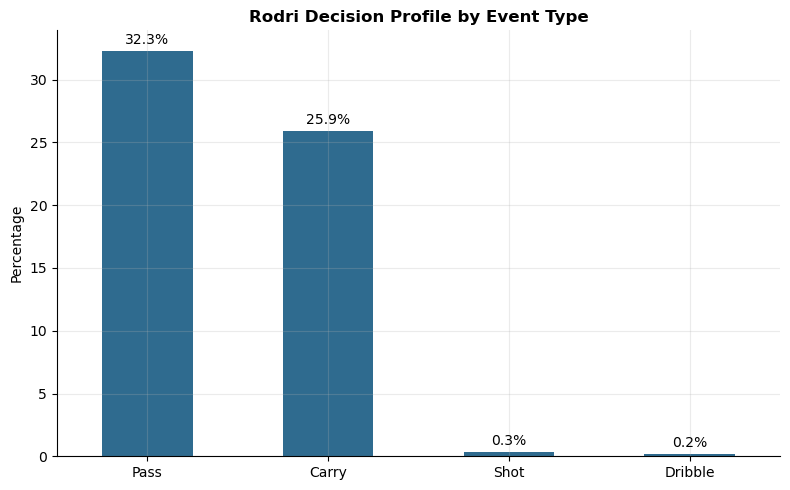

In [5]:
def add_bar_labels(ax, values, fmt="{:.1f}%", y_offset=0.01):
    """Aggiunge etichette leggibili sopra le barre verticali."""
    max_value = max(values) if len(values) else 0
    for patch, value in zip(ax.patches, values):
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            patch.get_height() + max_value * y_offset,
            fmt.format(value),
            ha="center",
            va="bottom",
            fontsize=10,
        )


def plot_percentage_bar(series, title, ylabel="Percentage", color="#2F6B8F"):
    values = series.mul(100)
    ax = values.plot(kind="bar", color=color)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    add_bar_labels(ax, values.values)
    plt.tight_layout()
    plt.show()


def plot_value_bar(series, title, ylabel, color="#577590", fmt="{:.2f}"):
    ax = series.plot(kind="bar", color=color)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    add_bar_labels(ax, series.values, fmt=fmt, y_offset=0.03)
    plt.tight_layout()
    plt.show()

decision_profile = (
    rodri_events["event_type"]
    .value_counts(normalize=True)
    .loc[lambda s: s.index.isin(["Pass", "Carry", "Shot", "Dribble"])]
    .sort_values(ascending=False)
)

display(decision_profile.to_frame("share"))
plot_percentage_bar(decision_profile, "Rodri Decision Profile by Event Type")


## 6. Analisi spaziale

Il passaggio successivo aggiunge il contesto spaziale. Ogni passaggio viene assegnato a una delle tre zone del campo usando la coordinata x di partenza:

- Difensiva: x < 40
- Centrale: 40 <= x < 80
- Offensiva: x >= 80

Questa scelta mantiene il modello semplice e facile da spiegare in un progetto portfolio.


,share
field_zone,
Defensive,0.201180
Central,0.677286
Offensive,0.121534


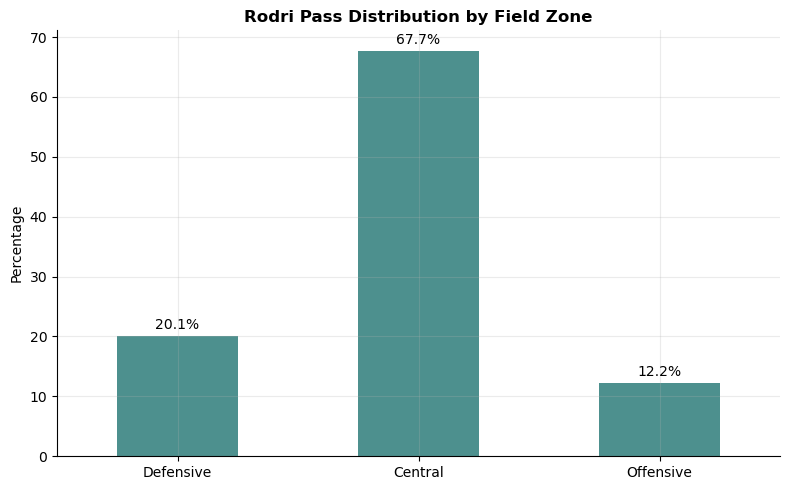

In [6]:
passes_by_zone = (
    rodri_passes["field_zone"]
    .value_counts(normalize=True)
    .reindex(ZONE_ORDER)
    .dropna()
)

display(passes_by_zone.to_frame("share"))
plot_percentage_bar(passes_by_zone, "Rodri Pass Distribution by Field Zone", color="#4D908E")


## 7. Direzione dei passaggi

La direzione del passaggio viene calcolata usando il movimento reale sulla coordinata x:

- Forward: end_x - start_x > 5
- Backward: end_x - start_x < -5
- Lateral: movimento compreso tra -5 e +5

La soglia di 5 metri evita di interpretare piccoli spostamenti come passaggi realmente progressivi o regressivi.


,share
pass_direction,
Forward,0.437168
Lateral,0.349263
Backward,0.213569


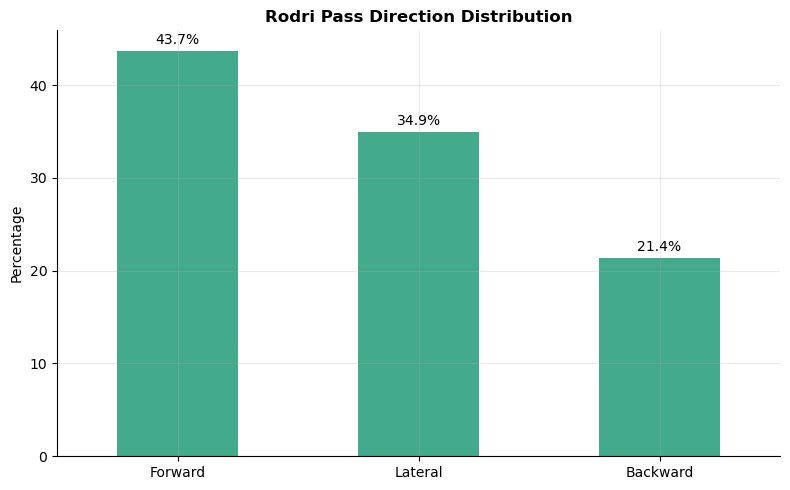

In [7]:
pass_direction_share = (
    rodri_passes["pass_direction"]
    .value_counts(normalize=True)
    .reindex(DIRECTION_ORDER)
    .dropna()
)

display(pass_direction_share.to_frame("share"))
plot_percentage_bar(pass_direction_share, "Rodri Pass Direction Distribution", color="#43AA8B")


pass_direction,Forward,Lateral,Backward
field_zone,,,
Defensive,0.530792,0.287390,0.181818
Central,0.420732,0.366725,0.212544
Offensive,0.373786,0.354369,0.271845


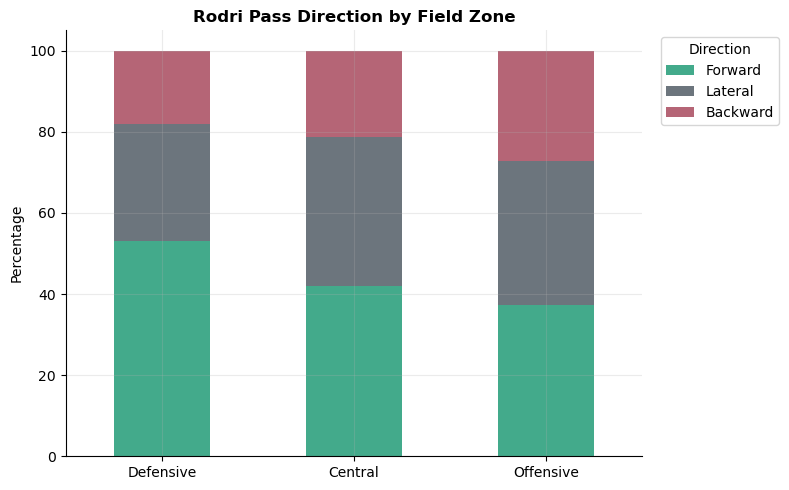

In [8]:
direction_by_zone = pd.crosstab(
    rodri_passes["field_zone"],
    rodri_passes["pass_direction"],
    normalize="index",
).reindex(index=ZONE_ORDER, columns=DIRECTION_ORDER)

display(direction_by_zone)

ax = direction_by_zone.mul(100).plot(
    kind="bar",
    stacked=True,
    color=["#43AA8B", "#6C757D", "#B56576"],
)
ax.set_title("Rodri Pass Direction by Field Zone")
ax.set_ylabel("Percentage")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Direction", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 8. Analisi della progressione

La progressione misura quanti metri il passaggio muove il pallone in avanti sull'asse x.

Valori positivi indicano che il passaggio fa avanzare il gioco. Valori negativi indicano che il passaggio muove il pallone all'indietro.


,progression
mean,3.648142
median,3.000000
std,12.026880
count,1695.000000


,mean,median,count
field_zone,,,
Defensive,6.177126,6.10,341
Central,3.333188,2.65,1148
Offensive,1.216990,1.45,206


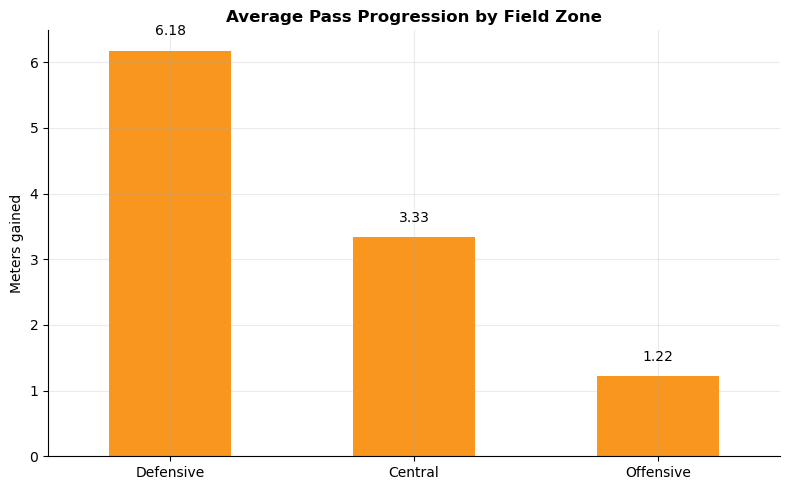

In [9]:
progression_summary = rodri_passes["progression"].agg(["mean", "median", "std", "count"])
progression_by_zone = (
    rodri_passes
    .groupby("field_zone")["progression"]
    .agg(["mean", "median", "count"])
    .reindex(ZONE_ORDER)
)

display(progression_summary.to_frame("progression"))
display(progression_by_zone)
plot_value_bar(
    progression_by_zone["mean"],
    "Average Pass Progression by Field Zone",
    ylabel="Meters gained",
    color="#F8961E",
)


## 9. Analisi della pressione

La pressione è una parte centrale del digital twin perché lo stesso giocatore può comportarsi in modo diverso quando viene pressato.

Qui confrontiamo la progressione dei passaggi di Rodri con e senza pressione, soprattutto nella zona difensiva, dove la pressione può influenzare molto la scelta.


,mean,median,count
pressure_label,,,
No pressure,3.904467,3.4,1455
Under pressure,2.094167,1.8,240


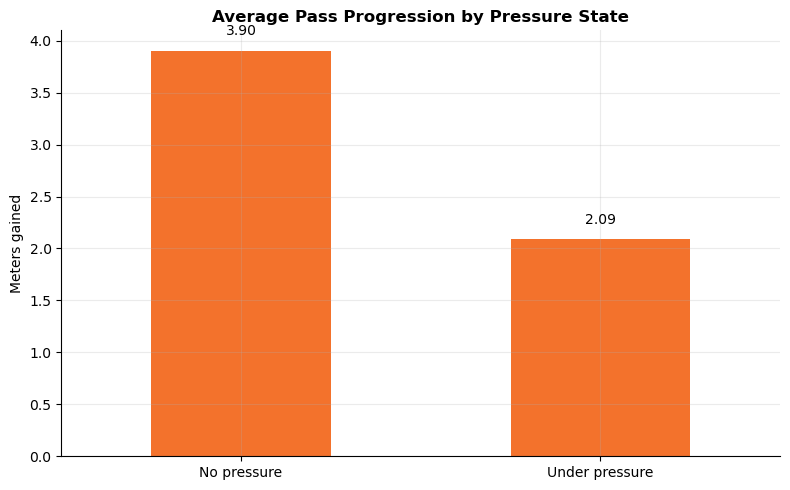

In [15]:
pressure_summary = (
    rodri_passes
    .groupby("pressure_label")["progression"]
    .agg(["mean", "median", "count"])
    .reindex(["No pressure", "Under pressure"])
)

display(pressure_summary)
plot_value_bar(
    pressure_summary["mean"],
    "Average Pass Progression by Pressure State",
    ylabel="Meters gained",
    color="#F3722C",
)


,mean,median,count
pressure_label,,,
No pressure,5.878893,5.9,289
Under pressure,7.834615,7.8,52


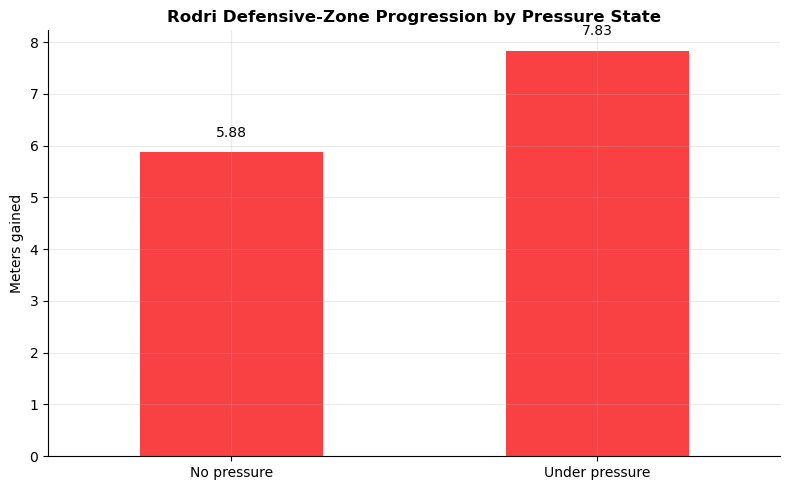

In [16]:
defensive_pressure = (
    rodri_passes
    .loc[rodri_passes["field_zone"].eq("Defensive")]
    .groupby("pressure_label")["progression"]
    .agg(["mean", "median", "count"])
    .reindex(["No pressure", "Under pressure"])
)

display(defensive_pressure)
plot_value_bar(
    defensive_pressure["mean"],
    "Rodri Defensive-Zone Progression by Pressure State",
    ylabel="Meters gained",
    color="#F94144",
)


## 10. Simulazione del Digital Twin

Il digital twin è un modello probabilistico interpretabile.

Per ogni combinazione di zona di campo e stato di pressione, il modello stima:

- probabilità di ogni direzione di passaggio
- progressione media per ogni direzione
- numerosità del campione usato per stimare la probabilità

Quando una combinazione richiesta non è presente nei dati, la simulazione usa un fallback più generale invece di fallire senza spiegazione.


In [12]:
def create_decision_model(passes):
    """Crea un modello decisionale probabilistico interpretabile per zona, pressione e direzione."""
    require_columns(
        passes,
        ["field_zone", "under_pressure", "pass_direction", "progression"],
        "passes",
    )

    grouped = (
        passes
        .groupby(["field_zone", "under_pressure", "pass_direction"], dropna=False)
        .agg(
            count=("pass_direction", "size"),
            avg_progression=("progression", "mean"),
            std_progression=("progression", "std"),
        )
        .reset_index()
    )

    total_by_context = grouped.groupby(["field_zone", "under_pressure"])["count"].transform("sum")
    grouped.loc[:, "probability"] = grouped["count"] / total_by_context
    grouped.loc[:, "pressure_label"] = grouped["under_pressure"].map(PRESSURE_LABELS)

    return grouped.sort_values(["field_zone", "under_pressure", "pass_direction"]).reset_index(drop=True)


def get_context_distribution(model, zone, under_pressure):
    """Restituisce le righe del modello per un contesto, con fallback per combinazioni mancanti."""
    require_columns(
        model,
        ["field_zone", "under_pressure", "pass_direction", "probability"],
        "model",
    )

    under_pressure = bool(under_pressure)
    context = model.loc[
        model["field_zone"].eq(zone) & model["under_pressure"].eq(under_pressure)
    ].copy()

    fallback_used = "exact context"

    if context.empty:
        context = model.loc[model["field_zone"].eq(zone)].copy()
        fallback_used = "zone-only fallback"

    if context.empty:
        context = model.copy()
        fallback_used = "global fallback"

    if context.empty:
        raise ValueError("The decision model is empty. Build it from valid pass data first.")

    # Ricalcola le probabilit? dopo il fallback.
    context = (
        context
        .groupby("pass_direction", as_index=False)
        .agg(
            count=("count", "sum"),
            avg_progression=("avg_progression", "mean"),
            std_progression=("std_progression", "mean"),
        )
    )
    context.loc[:, "probability"] = context["count"] / context["count"].sum()
    context.loc[:, "fallback_used"] = fallback_used

    return context


def simulate_player_behavior(model, zone, under_pressure, n=10, random_state=42):
    """Simula decisioni di passaggio simili a Rodri per zona e stato di pressione."""
    if zone not in ZONE_ORDER:
        raise ValueError(f"Unknown zone '{zone}'. Use one of: {ZONE_ORDER}")

    rng = np.random.default_rng(random_state)
    distribution = get_context_distribution(model, zone, under_pressure)

    directions = distribution["pass_direction"].to_numpy()
    probabilities = distribution["probability"].to_numpy()
    choices = rng.choice(directions, size=n, p=probabilities)

    lookup = distribution.set_index("pass_direction")
    rows = []

    for choice in choices:
        avg = lookup.loc[choice, "avg_progression"]
        std = lookup.loc[choice, "std_progression"]
        std = 0 if pd.isna(std) else std
        simulated_progression = rng.normal(avg, std) if std > 0 else avg

        rows.append({
            "zone": zone,
            "under_pressure": bool(under_pressure),
            "pressure_label": PRESSURE_LABELS[bool(under_pressure)],
            "simulated_direction": choice,
            "expected_progression": avg,
            "simulated_progression": simulated_progression,
            "fallback_used": distribution["fallback_used"].iloc[0],
        })

    return pd.DataFrame(rows)

model = create_decision_model(rodri_passes)
display(model.head(12))


,field_zone,under_pressure,pass_direction,count,avg_progression,std_progression,probability,pressure_label
0,Central,False,Backward,198,-11.616162,6.409957,0.199396,No pressure
1,Central,False,Forward,434,13.822350,8.327249,0.437059,No pressure
2,Central,False,Lateral,361,0.086427,2.691748,0.363545,No pressure
3,Central,True,Backward,46,-11.876087,5.290544,0.296774,Under pressure
4,Central,True,Forward,49,12.804082,6.098188,0.316129,Under pressure
5,Central,True,Lateral,60,0.255000,2.837964,0.387097,Under pressure
6,Defensive,False,Backward,54,-12.412963,6.309264,0.186851,No pressure
7,Defensive,False,Forward,152,15.319737,9.625580,0.525952,No pressure
8,Defensive,False,Lateral,83,0.490361,2.697678,0.287197,No pressure
9,Defensive,True,Backward,8,-11.587500,4.541063,0.153846,Under pressure


,zone,under_pressure,pressure_label,simulated_direction,expected_progression,simulated_progression,fallback_used
0,Defensive,True,Under pressure,Forward,17.251724,-5.801495,exact context
1,Defensive,True,Under pressure,Lateral,-0.013333,-0.801045,exact context
2,Defensive,True,Under pressure,Lateral,-0.013333,-4.260121,exact context
3,Defensive,True,Under pressure,Forward,17.251724,20.647173,exact context
4,Defensive,True,Under pressure,Forward,17.251724,19.213796,exact context
5,Defensive,True,Under pressure,Lateral,-0.013333,-0.639676,exact context
6,Defensive,True,Under pressure,Backward,-11.587500,-23.016264,exact context
7,Defensive,True,Under pressure,Lateral,-0.013333,-1.818312,exact context
8,Defensive,True,Under pressure,Lateral,-0.013333,-0.175844,exact context
9,Defensive,True,Under pressure,Forward,17.251724,18.670026,exact context


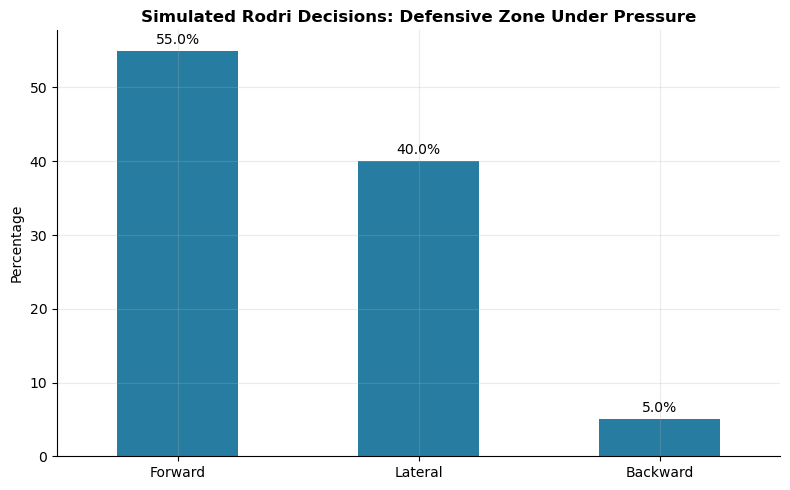

In [13]:
simulation = simulate_player_behavior(
    model=model,
    zone="Defensive",
    under_pressure=True,
    n=20,
    random_state=7,
)

display(simulation)

simulation_summary = simulation["simulated_direction"].value_counts(normalize=True).reindex(DIRECTION_ORDER).dropna()
plot_percentage_bar(
    simulation_summary,
    "Simulated Rodri Decisions: Defensive Zone Under Pressure",
    color="#277DA1",
)


## 11. Insight principali

Risultati principali sul campione di 24 match selezionati:

- Il profilo di passaggio di Rodri non è statico: cambia in base alla zona di campo e alla pressione.
- La quota di passaggi in avanti è più alta nelle zone basse, dove c'è più spazio da attaccare davanti al pallone.
- Nelle zone offensive, la progressione media diminuisce naturalmente perché resta meno campo da guadagnare.
- In zona difensiva, i passaggi sotto pressione possono mostrare una progressione media più alta: questo suggerisce che alcune situazioni di pressione forzano o invitano passaggi verticali di uscita.
- Il digital twin è utile perché collega le probabilità decisionali al contesto invece di descrivere solo medie globali.


## 12. Limiti

Questo è un modello analitico adatto a un portfolio, non un motore completo di simulazione del comportamento di un giocatore.

Limiti attuali:

- il modello usa solo dati evento, non tracking data
- la pressione è rappresentata come flag binario StatsBomb
- difficoltà del passaggio, orientamento del corpo, posizione degli avversari, qualità del ricevente e fase tattica non sono modellati
- la simulazione stima lo stile decisionale, non il successo del passaggio o l'ottimalità tattica
- alcune combinazioni zona-pressione possono avere campioni ridotti


## 13. Sviluppi futuri

Possibili miglioramenti:

- includere l'esito del passaggio
- separare gioco aperto, palle inattive e transizioni
- confrontare Rodri con centrocampisti simili
- aggiungere lunghezza e angolo del passaggio
- modellare la zona del ricevente e il valore dell'azione successiva
